# <ins>**"Make Like A Tree...", Exploring How Perspectives on Nature and Loneliness Affect Wellbeing.**</ins>

## <ins> Rationale </ins>

## <ins> Data Collection </ins>

In [10]:
# Imports relevant libraries.
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

from scipy.stats import shapiro

import pingouin as pg

import statsmodels.api as sm
import statsmodels.formula.api as smf 
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from statsmodels.stats.diagnostic import het_white
from statsmodels.multivariate.multivariate_ols import _MultivariateOLS

In [11]:
pd.options.display.float_format = "{:,.3f}".format

In [12]:
df = pd.read_pickle("data/people_nature_survey.pkl")

In [13]:
# Filters for the latest data.

df.columns = df.columns.str.lower()

df = df[df.wave.str.contains("September 2025")]

In [14]:
df_filtered = df[(df["m1"]=="Yes")&(df["m6"]=="Yes")]

Something to note is that module 2 asked respondents about recent visits to natural spaces. These responses were not explored in the current project. Respondents were split into subsets for modules 2-5. As such, it was difficult to determine how much of an impact that visits to green spaces had as some participants may not have provided responses. Additionally, the current project aimed to explore perceptions of natural spaces on the wellbeing measures, therefore including module 2 was beyond the scope of this project.

However, the current project acknowledged the possible impact that recent visits may have had on the results. The salience of a recent visit may cause individuals to feel more connected to nature. This may have caused respondents to have reported higher wellbeing scores.

### Extracting measures

#### Independent Variables
Attitudes towards nature consisted of 3 sections:
Module 1 Question 4 (a-g): General views on green and natural spaces.
Module 1 Question 5 (a-g): Views on local green and natural spaces.
Module 1 Question 6 (a-c): Connectedness with nature.

Loneliness was measured with a single question:
Module 6 Wellbeing_loneliness: How often the respondent felt lonely.

#### Dependent Variables
Both satisfaction and worthwhile scores were measured with a single question:
Module 6 Wellbeing satisfied: How satisfied the respondent felt with their life.
Module 6 Wellbeing worthwhile: How worthwhile did the things the respondents do in their life were.

#### Analytical Plan
To measure the effect of the variables on the outcomes, 2 multiple regression models were ran for satisfaction, and worthwhile respectively.

In [15]:
# Creates a list of all columns in the questions range. Filters dataframe for columns.

x_qs = list(range(list(df_filtered.columns).index(("m1_q4_a")),list(df_filtered.columns).index(("m1_q6_c"))+1))
y_qs = list(range(list(df_filtered.columns).index(("wellbeing_lonely")),list(df_filtered.columns).index(("wellbeing_worthwhile"))+1))

cols=[0]+ x_qs + y_qs

filt_df = df_filtered.iloc[
    :,
    cols
    ].reset_index(drop=True)

In [16]:
subset = [x for x in filt_df.isnull().sum().keys() if filt_df.isnull().sum()[x]>0]

filt_df = filt_df.dropna(how="any",axis=0,subset=subset).reset_index(drop=True)

In [17]:
filt_df.duplicated().sum()

np.int64(0)

In [18]:
# Drops rows for "don't knows", "prefer not to say"

drop_labels = ["Don’t know","Prefer not to say"]
drop_rows = set()
for x, y in filt_df.iterrows():
    for value in y:
        if value in drop_labels:
            drop_rows.add(x)

try:
    filt_df = filt_df.drop(drop_rows,axis=0)
except Exception as e:
    print(ValueError(e))

In [19]:
# Measures to rescore response labels.

temp_order = {"Completely disagree":1,
              "Strongly disagree": 2,
               "Disagree": 3,
                "Neither agree nor disagree": 4,
                "Agree": 5, 
                "Strongly agree": 6,
                "Completely agree": 7}

text_score = {"0 – Not at all":0,
              "10 – Completely":10}

lonely_score = {"Often / always":5,
                "Sometimes":4,
                "Occasionally":3,
                "Hardly ever": 2,
                "Never": 1}

In [20]:
try:
    filt_df = filt_df.map(lambda x: temp_order[x] if x in temp_order else x)
    filt_df = filt_df.map(lambda x: text_score[x] if x in text_score else x)
    filt_df = filt_df.map(lambda x: lonely_score[x] if x in lonely_score else x)
except Exception as e:
    print(ValueError(e))

In [21]:
# Converts all DV scores to floats.

try:
    filt_df.wellbeing_satisfied = filt_df.wellbeing_satisfied.astype(float)
    filt_df.wellbeing_worthwhile = filt_df.wellbeing_worthwhile.astype(float)
    filt_df.wellbeing_worthwhile = filt_df.wellbeing_worthwhile.astype(float)
except Exception as e:
    print(e)

In [22]:
print(
    "general_score",pg.cronbach_alpha(filt_df.loc[:,"m1_q4_a":"m1_q4_g"]),"\n",
    "local_score",pg.cronbach_alpha(filt_df.loc[:,"m1_q5_a":"m1_q5_g"]),"\n",
    "nature_score",pg.cronbach_alpha(filt_df.loc[:,"m1_q6_a":"m1_q6_c"])
)

general_score (np.float64(0.8805646503884574), array([0.862, 0.898])) 
 local_score (np.float64(0.8927298152847729), array([0.876, 0.908])) 
 nature_score (np.float64(0.8571032662734746), array([0.831, 0.88 ]))


Each of the nature-related measures scored within the commonly expected value of 0.70 (Taber, 2017). Therefore, each of the questions within their respective nature-related modules appeared to measure the same construct (Tavakol and Dennick, 2011). While, testing for reliability is often carried out during as a scale is being developed, the current project reported these values for exploratory analytical purposes.

In [23]:
filt_df["general_score"] = filt_df.loc[:,"m1_q4_a":"m1_q4_g"].T.mean()
filt_df["local_score"] = filt_df.loc[:,"m1_q5_a":"m1_q5_g"].T.mean()
filt_df["nature_score"] = filt_df.loc[:,"m1_q6_a":"m1_q6_c"].T.mean()

To produce scores for each of the nature-based perspective measures, the current project took the mean across each measure's questions.

In [24]:
predictors = filt_df[["nature_score","general_score", "local_score", "wellbeing_lonely"]]
outcomes = filt_df[["wellbeing_satisfied","wellbeing_worthwhile"]]

## <ins>Visualisation</ins>

Text(0.5, 1.0, 'Worthwhile Distribution')

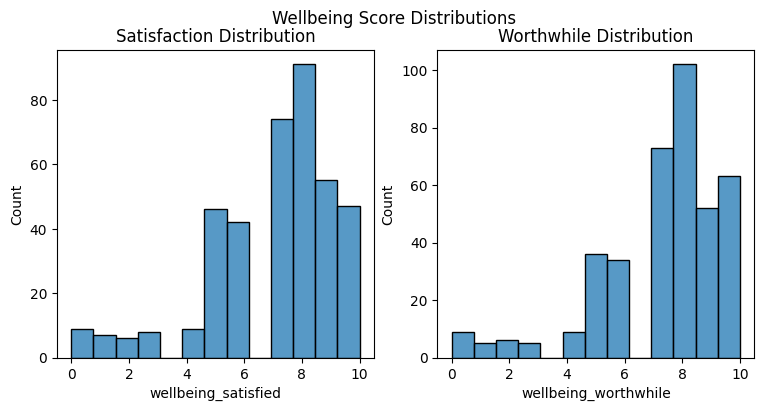

In [35]:
filt_df.iloc[:,-3:]
fig, ax = plt.subplots(1,2,figsize=(9,4))

fig.suptitle("Wellbeing Score Distributions")

sns.histplot(data=filt_df,x="wellbeing_satisfied",ax=ax[0])
ax[0].set_title("Satisfaction Distribution")

sns.histplot(data=filt_df,x="wellbeing_worthwhile",ax=ax[1])
ax[1].set_title("Worthwhile Distribution")

There was negative skew across both dependent variable's distributions.

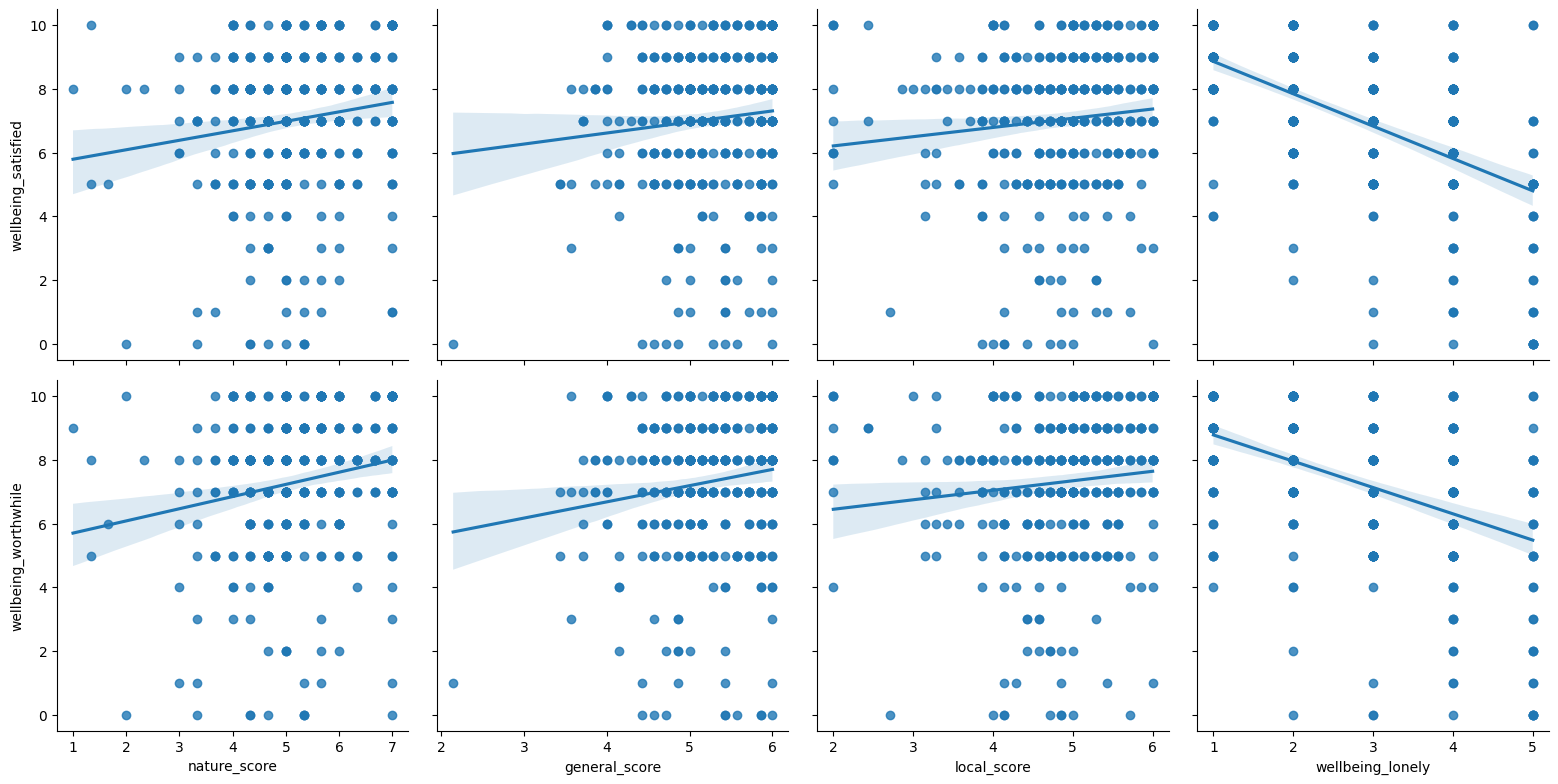

In [26]:
grid = sns.PairGrid(data=filt_df,y_vars=outcomes,x_vars=predictors,height=4)
grid.map(sns.regplot)

Scatter plots showed positive correlations between nature-based scores and the 2 dependent variables. Alternatively, lonliness negatively correlated with each of the wellbeing measures.   

## <ins>Multi-collinearity</ins>

In [27]:
vif_df = filt_df.loc[:,["general_score","local_score","nature_score","wellbeing_lonely"]]
vif_df = add_constant(vif_df)

In [28]:
vif_scores = pd.DataFrame()
vif_scores["features"] = vif_df.columns
vif_scores["VIF"] = [variance_inflation_factor(vif_df.values, i) for i in range(len(vif_df.columns))]
vif_scores

,features,VIF
0,const,99.754
1,general_score,1.201
2,local_score,1.152
3,nature_score,1.268
4,wellbeing_lonely,1.026


The variables show low levels of multi-collinearity across predictors, therefore all of the predictors will be included in the model.

## <ins>Multiple Regression</ins>

Both regression models were created with the "HC3" heteroskedasticity-consistent estimator, which are recommended in small sample sizes for creating robust standard errors.

In [29]:
satisfied_model = smf.ols("wellbeing_satisfied ~ general_score+local_score+nature_score+wellbeing_lonely",
    data=filt_df).fit(cov_type="HC3")

worthwhile_model = smf.ols("wellbeing_worthwhile ~ general_score+local_score+nature_score+wellbeing_lonely",
    data=filt_df).fit(cov_type="HC3")

## <ins>Results</ins>

### <ins>Satisfaction</ins>

satisfied_model

In [30]:
satisfied_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                            
===============================================================================
Dep. Variable:     wellbeing_satisfied   R-squared:                       0.321
Model:                             OLS   Adj. R-squared:                  0.314
Method:                  Least Squares   F-statistic:                     35.09
Date:                 Sat, 04 Apr 2026   Prob (F-statistic):           4.96e-25
Time:                         12:23:24   Log-Likelihood:                -803.98
No. Observations:                  394   AIC:                             1618.
Df Residuals:                      389   BIC:                             1638.
Df Model:                            4                                         
Covariance Type:                   HC3                                         
====================================================================================
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            8.6288      0.999      8.633      0.000       6.670      10.588
general_score        0.0612      0.236      0.260      0.795      -0.401       0.523
local_score          0.0637      0.136      0.469      0.639      -0.202       0.330
nature_score         0.1096      0.135      0.810      0.418      -0.156       0.375
wellbeing_lonely    -0.9959      0.086    -11.588      0.000      -1.164      -0.827
==============================================================================
Omnibus:                       39.468   Durbin-Watson:                   2.028
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               57.545
Skew:                          -0.686   Prob(JB):                     3.19e-13
Kurtosis:                       4.273   Cond. No.                         94.1
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
"""

The results showed that the regression was significant (F(4,389) = 35.09, R $ {^2}$ = .32, p< .001). Only loneliness was a significant predictor of satisfaction (β=-1.00, t= -11.59, p< .001). However, general score (β=0.06, t= 0.26, p = .795), local score (β=0.06, t= 0.47, p = 0.639), and nature score (β=0.11, t= 0.81, p< .418) had no significant effect. 

### <ins>Worthwhile</ins>

#### Model Summary

In [31]:
worthwhile_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                             
================================================================================
Dep. Variable:     wellbeing_worthwhile   R-squared:                       0.233
Model:                              OLS   Adj. R-squared:                  0.225
Method:                   Least Squares   F-statistic:                     23.29
Date:                  Sat, 04 Apr 2026   Prob (F-statistic):           2.84e-17
Time:                          12:23:24   Log-Likelihood:                -821.87
No. Observations:                   394   AIC:                             1654.
Df Residuals:                       389   BIC:                             1674.
Df Model:                             4                                         
Covariance Type:                    HC3                                         
====================================================================================
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            7.1846      1.049      6.852      0.000       5.130       9.240
general_score        0.2109      0.227      0.929      0.353      -0.234       0.656
local_score          0.0402      0.156      0.257      0.797      -0.266       0.346
nature_score         0.2001      0.138      1.446      0.148      -0.071       0.471
wellbeing_lonely    -0.7899      0.091     -8.664      0.000      -0.969      -0.611
==============================================================================
Omnibus:                       70.801   Durbin-Watson:                   2.125
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              123.785
Skew:                          -1.032   Prob(JB):                     1.32e-27
Kurtosis:                       4.811   Cond. No.                         94.1
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
"""

The results showed that the regression was significant (F(4,389) = 23.29, R ${^2}$ = .23, p< .001). Only loneliness was a significant predictor of satisfaction (β=-0.79, t= -8.66, p< .001). However, general score (β=0.21, t= 0.93, p = .353), local score (β=0.04, t= 0.26, p = 0.797), and nature score (β=0.20, t= 1.45, p< .148) had no significant effect. 

### Residual Plots

Text(0.5, 0.98, 'Model Plots of Nature Perspective Predictors.')

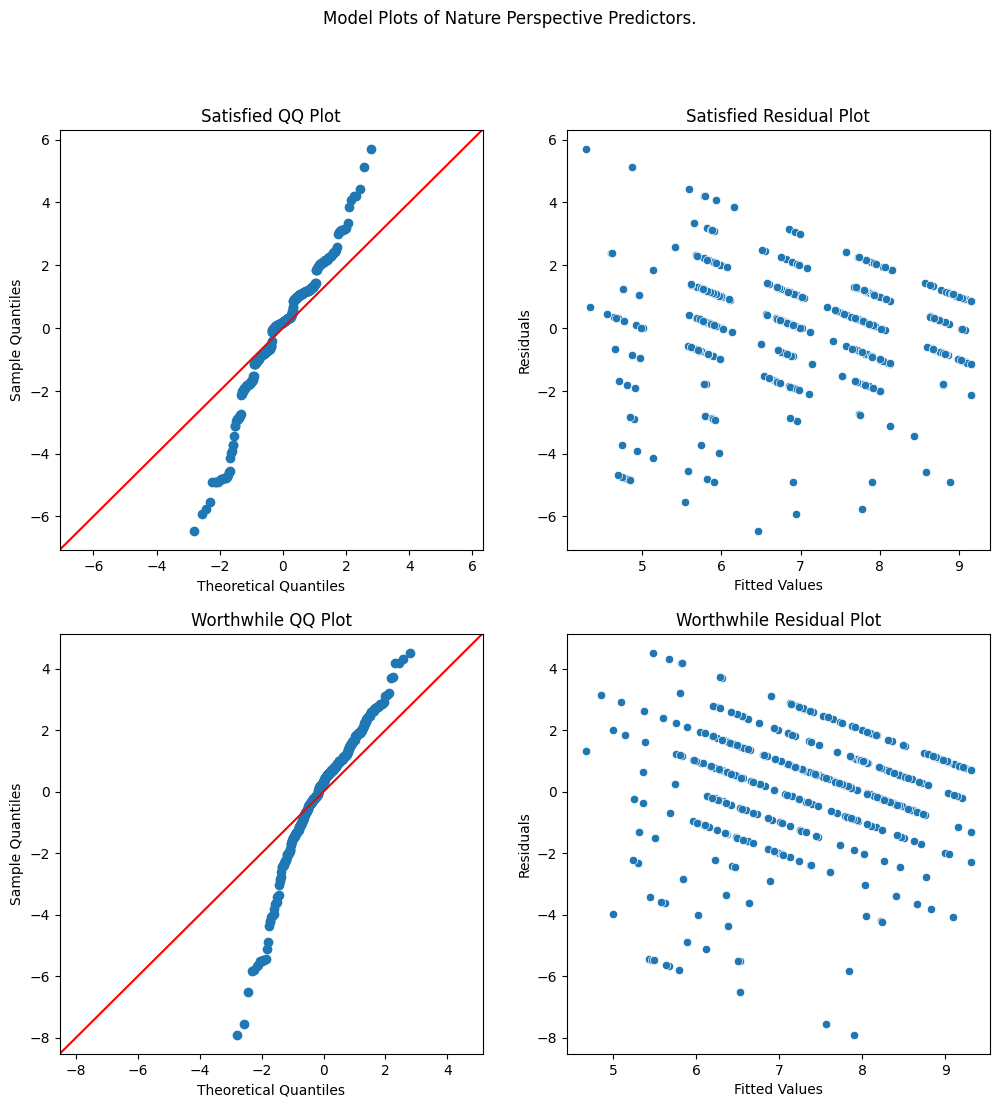

In [36]:
satnr_resids = satisfied_model.resid
wwnr_resids = worthwhile_model.resid


fig, ax = plt.subplots(2,2,figsize=(12,12))

#Satisfied
sm.qqplot(satnr_resids,line="45",ax=ax[0,0])
ax[0,0].set_title("Satisfied QQ Plot")

sns.scatterplot(x=satisfied_model.fittedvalues,y=satnr_resids,ax=ax[0,1])
ax[0,1].set_ylabel("Residuals")
ax[0,1].set_xlabel("Fitted Values")
ax[0,1].set_title("Satisfied Residual Plot")

#Worthwhile
sm.qqplot(wwnr_resids,line="45",ax=ax[1,0])
ax[1,0].set_title("Worthwhile QQ Plot")

sns.scatterplot(x=worthwhile_model.fittedvalues,y=wwnr_resids,ax=ax[1,1])
ax[1,1].set_ylabel("Residuals")
ax[1,1].set_xlabel("Fitted Values")
ax[1,1].set_title("Worthwhile Residual Plot")

fig.suptitle("Model Plots of Nature Perspective Predictors.")

### Normality

In [33]:
stat,p = shapiro(satnr_resids)
print(f"Satisfied:\nstatistic: {stat},\np-value: {p}")
stat,p = shapiro(wwnr_resids)
print(f"Worthwhile:\nstatistic: {stat},\np-value: {p}")

Satisfied:
statistic: 0.9530271656878609,
p-value: 7.056899431478714e-10
Worthwhile:
statistic: 0.9399800746568188,
p-value: 1.6007687005806314e-11


The QQ plot showed that the residuals were not normally distributed. This is supported by a significant Shapiro-Wilk test which indicated non-normality (W=0.95,p<0.001). Literature discusses that this is a basic assumption for linear regression (Tsagris and Pandis, 2021). However, in larger datasets (10 individuals per predictor) non-normality may not limit the validity of the results (Lott, 2015; Schmidt and Finan, 2018). As there were 183 individuals in this dataset, non-normality was not needing addressed.

### Heteroskedasticity

In [34]:
predictors = sm.add_constant(predictors)

lm= het_white(satnr_resids,predictors)
print(f"Satisfied:\nstatistic: {lm[0]},\np-value: {lm[1]}")
lm= het_white(wwnr_resids,predictors)
print(f"Worthwhile:\nstatistic: {lm[0]},\np-value: {lm[1]}")

Satisfied:
statistic: 65.42135251415,
p-value: 1.2864585705731817e-08
Worthwhile:
statistic: 44.58251886181424,
p-value: 4.767007696324166e-05


White's test for heteroskedasticity was significant (χ<sup>2</sup>(4,178) = 27.68, p < 0.001) therefore homoskedasticity could not be assumed. However as the model used the HC3 standard error matrix, often used when the assumptions of homoskedasticity have been violated (Rajh-Weber et al., 2025).

## <ins>References</ins>

Lott, J. P. (2015). A note on normality. Journal of the American Academy of Dermatology, 72(6), e169–e170. https://doi.org/10.1016/j.jaad.2015.01.051

Natural England. (2026). People and Nature Survey for England, 2020-2025. 2026. 12th Edition. UK Data Service. SN: 9093, DOI: http://doi.org/10.5255/UKDA-SN-9093-12

Rajh-Weber, H., Huber, S., & Arendasy, M. (2025). Using heteroskedasticity-consistent standard errors and the bootstrap for linear regression analysis in SPSS: A tutorial. https://doi.org/10.1177/25152459251408046

Schmidt, A. F., & Finan, C. (2018). Linear regression and the normality assumption. Journal of Clinical Epidemiology, 98, 146–151. https://doi.org/10.1016/j.jclinepi.2017.12.006

Taber, K. S. (2017). The Use of Cronbach’s Alpha When Developing and Reporting Research Instruments in Science Education. Research in Science Education, 48(6), 1273–1296. https://doi.org/10.1007/s11165-016-9602-2

Tavakol, M., & Dennick, R. (2011). Making sense of Cronbach’s alpha. International Journal of Medical Education, 2, 53–55. https://doi.org/10.5116/ijme.4dfb.8dfd

Tsagris, M., & Pandis, N. (2021). Normality test: Is it really necessary? American Journal of Orthodontics and Dentofacial Orthopedics, 159(4), 548–549. https://doi.org/10.1016/j.ajodo.2021.01.003